Running pursuer R_min = inf evader R_min = inf
R_min = inf, Re_min = inf: Time limit reached (t = 100.00 s) — no capture or encirclement
Running pursuer R_min = 30.0 evader R_min = inf
R_min = 30.0, Re_min = inf: Time limit reached (t = 100.00 s) — no capture or encirclement
Running pursuer R_min = 15.0 evader R_min = inf
R_min = 15.0, Re_min = inf: Time limit reached (t = 100.00 s) — no capture or encirclement
Running pursuer R_min = 8.0 evader R_min = inf
R_min = 8.0, Re_min = inf: Time limit reached (t = 100.00 s) — no capture or encirclement
Running pursuer R_min = 4.0 evader R_min = inf
R_min = 4.0, Re_min = inf: Time limit reached (t = 100.00 s) — no capture or encirclement


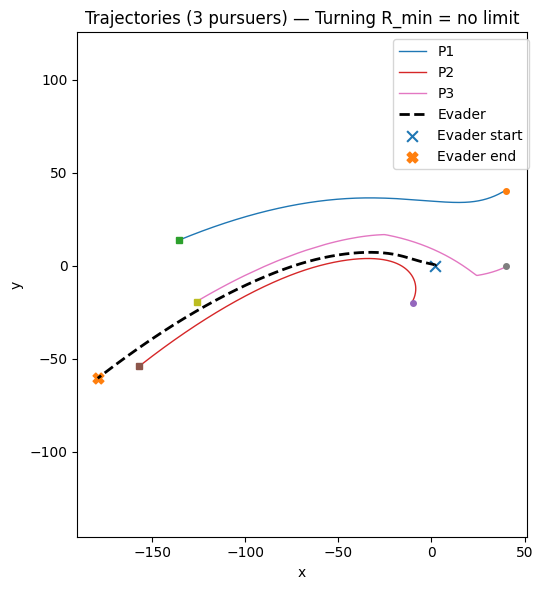

Saved: figures_3pursuer_turning/3pursuer_turning_trajectories_nolimit.png


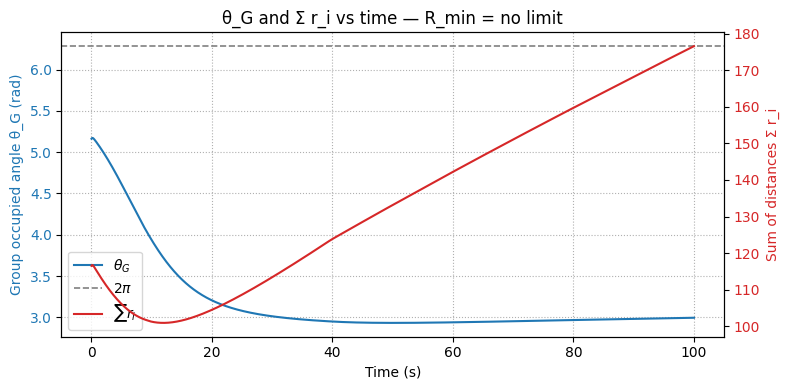

Saved: figures_3pursuer_turning/3pursuer_turning_theta_sumr_nolimit.png


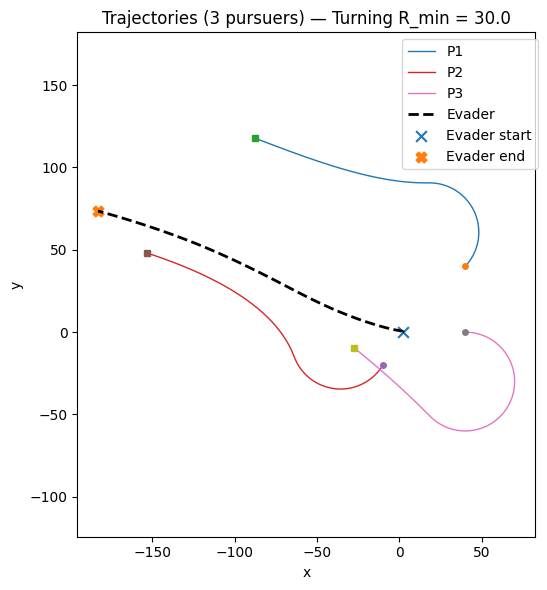

Saved: figures_3pursuer_turning/3pursuer_turning_trajectories_R30.0.png


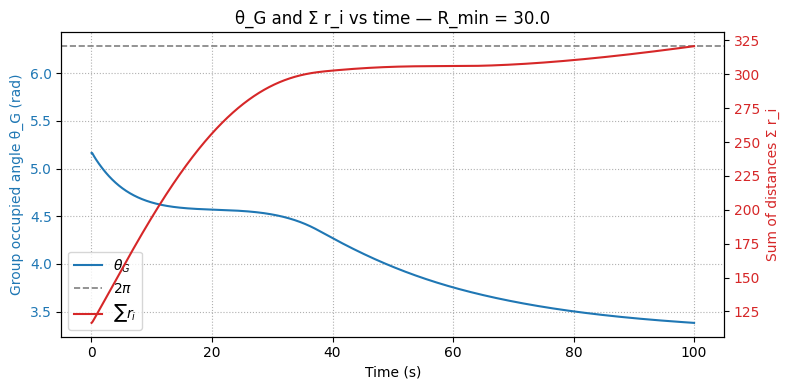

Saved: figures_3pursuer_turning/3pursuer_turning_theta_sumr_R30.0.png


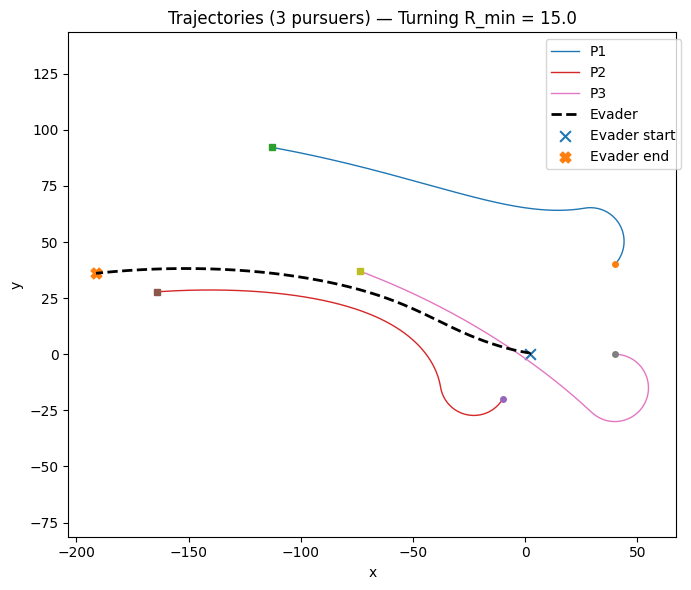

Saved: figures_3pursuer_turning/3pursuer_turning_trajectories_R15.0.png


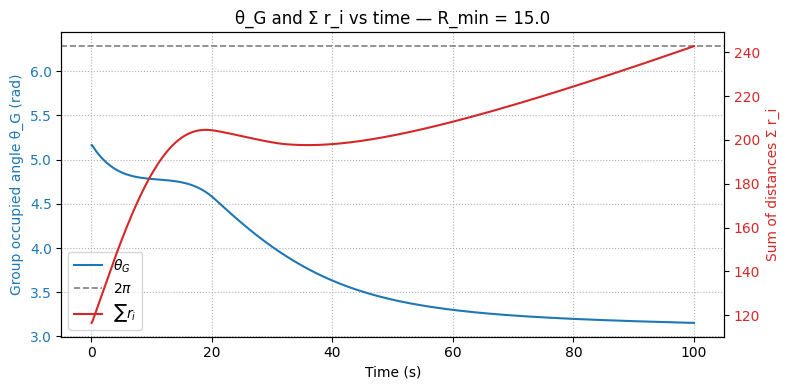

Saved: figures_3pursuer_turning/3pursuer_turning_theta_sumr_R15.0.png


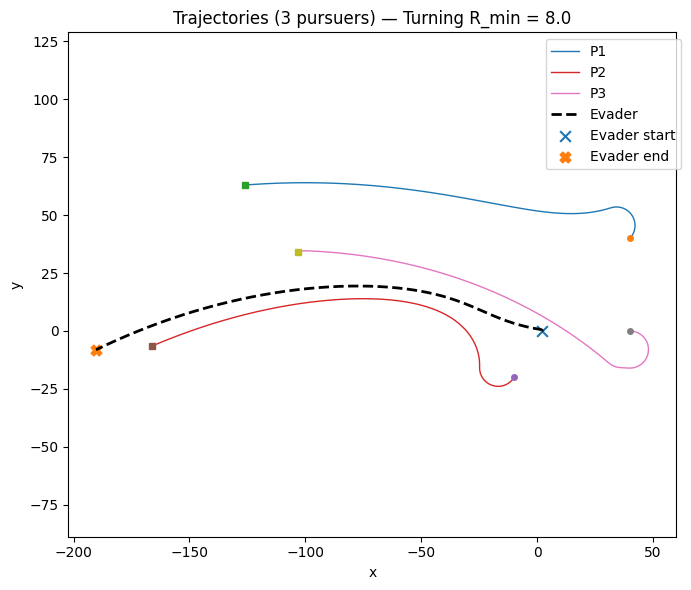

Saved: figures_3pursuer_turning/3pursuer_turning_trajectories_R8.0.png


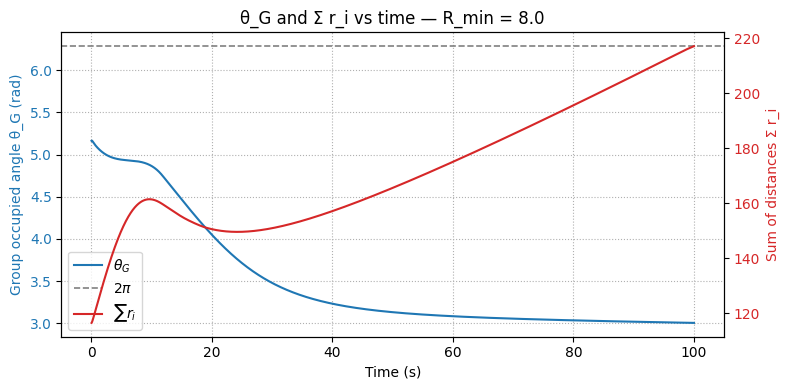

Saved: figures_3pursuer_turning/3pursuer_turning_theta_sumr_R8.0.png


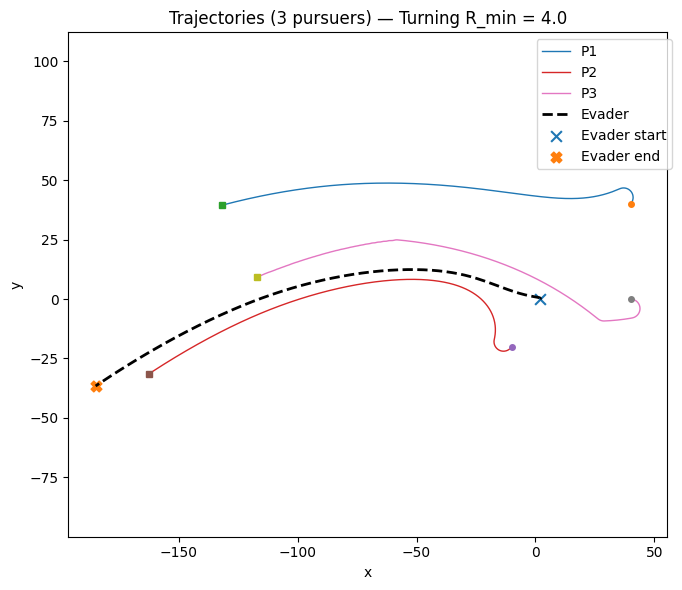

Saved: figures_3pursuer_turning/3pursuer_turning_trajectories_R4.0.png


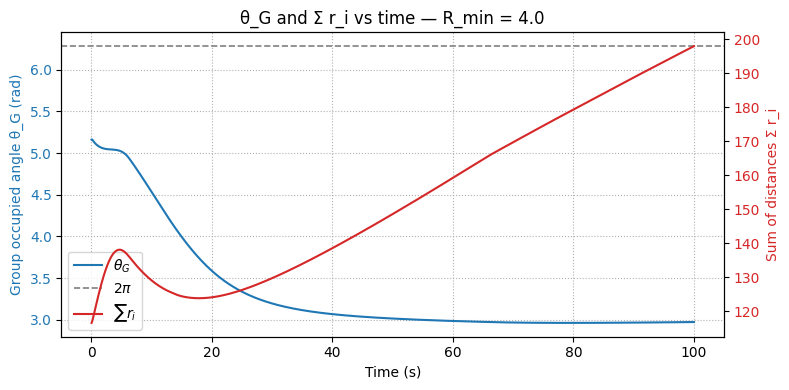

Saved: figures_3pursuer_turning/3pursuer_turning_theta_sumr_R4.0.png


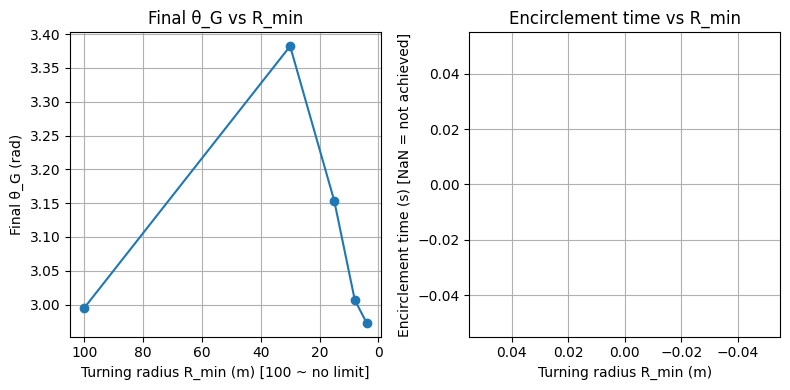

Saved summary: figures_3pursuer_turning/3pursuer_turning_summary_theta_enc_time.png
All figures saved to figures_3pursuer_turning


In [ ]:
# -------------------------
# 3-pursuer simulation with turning-circle radius limit + plotting/saving
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
import os
from math import pi, atan2

# -------------------------
# Attempt to reuse helpers if present; otherwise define minimal versions
# -------------------------
try:
    compute_polar, theta_from_lambda, compute_eps_sorted
    compute_beta, compute_k_h, compute_vis, compute_vih, evader_control
except Exception:
    # minimal helper implementations (paper-style)
    from math import sin, cos, asin
    def wrap2pi(a): return a % (2*np.pi)
    def norm(v): return np.linalg.norm(v)

    def compute_polar(pursuers, evader):
        N = pursuers.shape[0]
        r = np.zeros(N); alphas = np.zeros(N); rels = np.zeros((N,2))
        for i in range(N):
            rel = pursuers[i] - evader
            rels[i] = rel
            r[i] = norm(rel)
            alphas[i] = wrap2pi(atan2(rel[1], rel[0]))
        return r, alphas, rels

    def theta_from_lambda(lambda_i):
        lam = np.clip(lambda_i, -0.999999, 0.999999)
        return 2.0 * np.arcsin(abs(lam))

    def compute_eps_sorted(alphas, thetas):
        order = np.argsort(alphas)
        a = alphas[order]
        th = thetas[order]
        N = len(a)
        eps = np.zeros(N)
        for k in range(N):
            j = (k+1)%N
            diff = (a[j] - a[k]) % (2*np.pi)
            eps[k] = diff - 0.5*(th[j] + th[k])
        return order, eps

    def compute_beta(delta_i, gamma_i):
        return (pi/2.0) * (1.0 - np.exp(-delta_i * gamma_i))

    def compute_k_h(Vi, beta_i, r_i, eps_diff, small_eps=1e-6):
        r_safe = max(r_i, small_eps)
        sinb = np.sin(beta_i); cosb = np.cos(beta_i)
        if abs(eps_diff) > 1e-6:
            k_i = (Vi * sinb) / ( r_safe * abs(eps_diff) )
        else:
            k_i = 1.0
        h_i = (Vi * cosb) / r_safe
        return k_i, h_i

    def compute_vis(alpha_dot, r_i, alpha):
        vx = alpha_dot * r_i * (-np.sin(alpha))
        vy = alpha_dot * r_i * ( np.cos(alpha))
        return np.array([vx, vy])

    def compute_vih(h_i, r_i, alpha):
        vx = - h_i * r_i * np.cos(alpha)
        vy = - h_i * r_i * np.sin(alpha)
        return np.array([vx, vy])

    def evader_control(evader_pos, pursuers_pos, Ve, ke=140.0):
        f = np.zeros(2)
        for p in pursuers_pos:
            rel = evader_pos - p
            d = norm(rel)
            if d > 1e-6:
                f += ke * (rel / d)
        f += 0.001 * evader_pos
        fd = f / max(norm(f), 1e-9)
        return Ve * fd

# -------------------------
# 3-pursuer config (paper values)
# -------------------------
def config_3pursuer_paper():
    cfg = {}
    cfg['case_name'] = '3pursuer_turning'
    cfg['Ve'] = 2.0
    cfg['lambda'] = 0.9
    cfg['Vi'] = cfg['lambda'] * cfg['Ve']
    cfg['pursuers0'] = np.array([[40.,40.], [-10.,-20.], [40.,0.]])
    cfg['evader0'] = np.array([2.,0.])
    cfg['dc'] = 1.0
    cfg['ke'] = 140.0
    return cfg

def simulate_3pursuer_with_turning(cfg, R_list, dt=0.01, max_t=float("inf"), verbose=False, Re_min=np.inf):
    """
    Simulate 3-pursuer pursuit–evasion with optional turning limits on both pursuers and evader.

    Parameters
    ----------
    cfg : dict
        Configuration with fields:
        - 'pursuers0': (N×2) array, initial pursuer positions
        - 'evader0': (2,) array, initial evader position
        - 'Vi', 'Ve': pursuer and evader speeds
        - 'lambda': geometry constant
        - 'dc': capture distance
        - 'ke': optional evader control gain
    R_list : list
        List of minimum turning radii for pursuers (np.inf for holonomic case)
    Re_min : float
        Minimum turning radius for evader (np.inf for no limit)
    dt : float
        Simulation step size
    max_t : float
        Max simulation time
    verbose : bool
        Print progress if True
    """
    results = {}
    N = cfg['pursuers0'].shape[0]
    for R in R_list:
        if verbose:
            print("Running pursuer R_min =", R, "evader R_min =", Re_min)

        # initial states
        purs_pos = cfg['pursuers0'].astype(float).copy()
        ev_pos = cfg['evader0'].astype(float).copy()

        purs_heading = np.zeros(N)
        for i in range(N):
            purs_heading[i] = atan2(purs_pos[i, 1] - ev_pos[1], purs_pos[i, 0] - ev_pos[0])

        ev_heading = 0.0  # initial evader heading

        # turning limits
        w_max_p = cfg['Vi'] / R if np.isfinite(R) else None
        w_max_e = cfg['Ve'] / Re_min if np.isfinite(Re_min) else None

        # recorders
        times = []
        traj_p = [purs_pos.copy()]
        traj_e = [ev_pos.copy()]
        thetaG_list = []
        sumr_list = []

        t = 0.0
        captured = False
        k_heading = 6.0  # heading controller gain

        while t < max_t:
            # --- Compute control law (same as before) ---
            r, alphas, rels = compute_polar(purs_pos, ev_pos)
            thetas = np.array([theta_from_lambda(cfg['lambda'])] * N)
            order, eps = compute_eps_sorted(alphas, thetas)

            # compute control terms (k, h, beta, etc.)
            thetas_sorted = thetas[order]
            r_sorted = r[order]
            eps_diff_sorted = np.zeros(N)
            for i_s in range(N):
                eps_diff_sorted[i_s] = eps[i_s] - eps[(i_s - 1) % N]

            k_vals_sorted = np.zeros(N)
            h_vals_sorted = np.zeros(N)
            beta_sorted = np.zeros(N)
            for i_s in range(N):
                im1_s = (i_s - 1) % N
                ip1_s = (i_s + 1) % N
                denom = max(1e-6, 4 * pi - thetas_sorted[ip1_s] - thetas_sorted[im1_s]) if N > 2 else 1.0
                delta_i = 2.0 * abs(eps[i_s]) / denom
                ssum = r_sorted[i_s] + r_sorted[im1_s] + r_sorted[ip1_s]
                gamma_i = np.sin(pi * (r_sorted[i_s] / ssum) * np.log2(3.0)) if ssum > 1e-9 else 0.0
                beta_i = compute_beta(delta_i, gamma_i)
                beta_sorted[i_s] = beta_i
                k_i, h_i = compute_k_h(cfg['Vi'], beta_i, r_sorted[i_s], eps_diff_sorted[i_s])
                k_vals_sorted[i_s] = k_i
                h_vals_sorted[i_s] = h_i

            def compute_alpha_dot_from_eps_local(eps_arr, k_arr):
                Nloc = len(eps_arr)
                ad = np.zeros(Nloc)
                for ii in range(Nloc):
                    im1 = (ii - 1) % Nloc
                    ad[ii] = k_arr[ii] * (eps_arr[ii] - eps_arr[im1])
                return ad
+

            alpha_dot_sorted = compute_alpha_dot_from_eps_local(eps, k_vals_sorted)
            alpha_dot = np.zeros(N)
            k_vals = np.zeros(N)
            h_vals = np.zeros(N)
            for idx_s, orig_idx in enumerate(order):
                alpha_dot[orig_idx] = alpha_dot_sorted[idx_s]
                k_vals[orig_idx] = k_vals_sorted[idx_s]
                h_vals[orig_idx] = h_vals_sorted[idx_s]

            # --- Nominal velocities ---
            v_nom = np.zeros((N, 2))
            for i in range(N):
                vis = compute_vis(alpha_dot[i], r[i], alphas[i])
                vih = compute_vih(h_vals[i], r[i], alphas[i])
                v_comb = vis + vih
                if np.linalg.norm(v_comb) < 1e-9:
                    if r[i] > 1e-9:
                        v_comb = cfg['Vi'] * (-rels[i] / r[i])
                    else:
                        v_comb = np.array([cfg['Vi'], 0.0])
                if np.linalg.norm(v_comb) > cfg['Vi']:
                    v_comb = cfg['Vi'] * (v_comb / np.linalg.norm(v_comb))
                v_nom[i] = v_comb

            # --- Evader nominal ---
            v_e_nom = evader_control(ev_pos, purs_pos, cfg['Ve'], ke=cfg.get('ke', 140.0))

            # --- Pursuer updates (turning-limited) ---
            for i in range(N):
                desired_heading = atan2(v_nom[i, 1], v_nom[i, 0])
                heading_err = (desired_heading - purs_heading[i] + np.pi) % (2 * np.pi) - np.pi
                w_cmd = k_heading * heading_err
                if w_max_p is not None:
                    w_cmd = np.clip(w_cmd, -w_max_p, w_max_p)
                purs_heading[i] += w_cmd * dt
                purs_pos[i, 0] += cfg['Vi'] * np.cos(purs_heading[i]) * dt
                purs_pos[i, 1] += cfg['Vi'] * np.sin(purs_heading[i]) * dt

            # --- Evader update (turning-limited now) ---
            desired_e_heading = atan2(v_e_nom[1], v_e_nom[0])
            heading_err_e = (desired_e_heading - ev_heading + np.pi) % (2 * np.pi) - np.pi
            w_e_cmd = k_heading * heading_err_e
            if w_max_e is not None:
                w_e_cmd = np.clip(w_e_cmd, -w_max_e, w_max_e)
            ev_heading += w_e_cmd * dt
            ev_pos[0] += cfg['Ve'] * np.cos(ev_heading) * dt
            ev_pos[1] += cfg['Ve'] * np.sin(ev_heading) * dt

            # --- record metrics ---
            t += dt
            times.append(t)
            traj_p.append(purs_pos.copy())
            traj_e.append(ev_pos.copy())

            r2, alphas2, _ = compute_polar(purs_pos, ev_pos)
            thetas2 = np.array([theta_from_lambda(cfg['lambda'])] * N)
            _, eps2 = compute_eps_sorted(alphas2, thetas2)
            thetaG = np.sum(thetas2) + np.sum(np.minimum(0.0, eps2))
            thetaG_list.append(thetaG)
            sumr_list.append(np.sum(r2))

            if np.any(r2 <= cfg['dc']):
                captured = True
                if verbose:
                    print(f"Captured at t = {t:.3f}")
                break

        # --- Post-processing ---
        theta_arr = np.array(thetaG_list)
        enc_idx = np.where(theta_arr >= 2 * np.pi - 1e-3)[0]
        enc_time = float(times[enc_idx[0]]) if enc_idx.size > 0 else None
        final_theta = float(theta_arr[-1]) if theta_arr.size > 0 else None

        reason = (
            f"Capture achieved at t = {t:.2f} s" if captured
            else f"Encirclement achieved (θ_G ≥ 2π) at t = {enc_time:.2f} s" if enc_time is not None
            else f"Time limit reached (t = {t:.2f} s) — no capture or encirclement"
        )

        print(f"R_min = {R}, Re_min = {Re_min}: {reason}")

        results[R] = {
            'times': np.array(times),
            'traj_p': np.array(traj_p),
            'traj_e': np.array(traj_e),
            'thetaG': np.array(thetaG_list),
            'sumr': np.array(sumr_list),
            'enc_time': enc_time,
            'final_theta': final_theta,
            'captured': captured,
        }

    return results


# -------------------------
# Run sweep and produce/save figures
# -------------------------
cfg3 = config_3pursuer_paper()
# choose turning radii to test (m). Use np.inf for no limit (pure kinematic)
R_test = [np.inf, 30.0, 15.0, 8.0, 4.0]   # adjust list as you like

res_map = simulate_3pursuer_with_turning(cfg3, R_test, dt=0.01, max_t=100.0, verbose=True)

out_dir = "figures_3pursuer_turning"
os.makedirs(out_dir, exist_ok=True)

# Per-R plots (trajectories + dual axis) and saving
for R in R_test:
    key = R
    res = res_map[key]
    times = res['times']
    traj_p = res['traj_p']
    traj_e = res['traj_e']
    thetaG = res['thetaG']
    sumr = res['sumr']
    N = traj_p.shape[1]

    # label for file names
    label = "nolimit" if not np.isfinite(R) else f"R{float(R):.1f}"

    # Trajectories
    fig, ax = plt.subplots(figsize=(7,6))
    for i in range(N):
        ax.plot(traj_p[:,i,0], traj_p[:,i,1], '-', linewidth=1, label=f'P{i+1}')
        ax.plot(traj_p[0,i,0], traj_p[0,i,1], 'o', markersize=4)
        ax.plot(traj_p[-1,i,0], traj_p[-1,i,1], 's', markersize=4)
    ax.plot(traj_e[:,0], traj_e[:,1], 'k--', linewidth=2, label='Evader')
    ax.scatter(traj_e[0,0], traj_e[0,1], marker='x', s=60, label='Evader start')
    ax.scatter(traj_e[-1,0], traj_e[-1,1], marker='X', s=60, label='Evader end')
    ax.set_title(f"Trajectories (3 pursuers) — Turning R_min = {('no limit' if not np.isfinite(R) else R)}")
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.axis('equal')
    ax.legend(loc='best', bbox_to_anchor=(1.02,1.0))
    plt.tight_layout()
    fpath = os.path.join(out_dir, f"{cfg3['case_name']}_trajectories_{label}.png")
    fig.savefig(fpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fpath)

    # Dual-axis plot: thetaG + sumr
    # align arrays lengths
    minlen = min(len(times), len(thetaG), len(sumr))
    t_plot = times[:minlen]; theta_plot = thetaG[:minlen]; sumr_plot = sumr[:minlen]

    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(t_plot, theta_plot, color='tab:blue', label=r'$\theta_G$')
    ax1.axhline(2*np.pi, color='gray', linestyle='--', linewidth=1.2, label=r'$2\pi$')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Group occupied angle θ_G (rad)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle=':')

    ax2 = ax1.twinx()
    ax2.plot(t_plot, sumr_plot, color='tab:red', label=r'$\sum r_i$')
    ax2.set_ylabel('Sum of distances Σ r_i', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines+lines2, labels+labels2, loc='best')

    plt.title(f'θ_G and Σ r_i vs time — R_min = {("no limit" if not np.isfinite(R) else R)}')
    plt.tight_layout()
    fpath2 = os.path.join(out_dir, f"{cfg3['case_name']}_theta_sumr_{label}.png")
    fig.savefig(fpath2, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fpath2)

# -------------------------
# Combined summary plot: final thetaG and encirclement time vs R
# -------------------------
Rvals = []; final_theta = []; enc_time = []; captured_flags = []
for R in R_test:
    v = res_map[R]
    Rvals.append(np.nan if not np.isfinite(R) else R)
    final_theta.append(v['final_theta'])
    enc_time.append(v['enc_time'] if v['enc_time'] is not None else np.nan)
    captured_flags.append(v['captured'])

# Use an x-axis where 'no limit' is placed at large R for visualization
x_vals = [100.0 if np.isnan(r) else r for r in Rvals]

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(x_vals, final_theta, '-o')
plt.xlabel('Turning radius R_min (m) [100 ~ no limit]')
plt.ylabel('Final θ_G (rad)')
plt.title('Final θ_G vs R_min')
plt.gca().invert_xaxis()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x_vals, enc_time, '-o')
plt.xlabel('Turning radius R_min (m)')
plt.ylabel('Encirclement time (s) [NaN = not achieved]')
plt.title('Encirclement time vs R_min')
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
summary_path = os.path.join(out_dir, f"{cfg3['case_name']}_summary_theta_enc_time.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved summary:", summary_path)

# done
print("All figures saved to", out_dir)


In [2]:
import numpy as np
from math import pi, sin, cos, atan2

# ---------- Helper: compute thetaG (paper definition) ----------
def compute_polar(pursuers, evader):
    rel = pursuers - evader[None,:]
    r = np.linalg.norm(rel, axis=1)
    alphas = np.arctan2(rel[:,1], rel[:,0]) % (2*np.pi)
    return r, alphas, rel

def theta_from_lambda(lambda_i):
    lam = np.clip(lambda_i, -0.999999, 0.999999)
    return 2.0 * np.arcsin(abs(lam))

def compute_eps_sorted(alphas, thetas):
    order = np.argsort(alphas)
    a_sorted = alphas[order]
    theta_sorted = thetas[order]
    N = len(a_sorted)
    eps = np.zeros(N)
    for k in range(N):
        j = (k+1) % N
        gap = (a_sorted[j] - a_sorted[k]) % (2*np.pi)
        eps[k] = gap - 0.5*(theta_sorted[j] + theta_sorted[k])
    return order, eps

def compute_thetaG(pursuers, evader, lambda_i):
    r, alphas, _ = compute_polar(pursuers, evader)
    thetas = np.array([theta_from_lambda(lambda_i)] * len(r))
    _, eps = compute_eps_sorted(alphas, thetas)
    thetaG = np.sum(thetas) + np.sum(np.minimum(0.0, eps))
    return float(thetaG)

# ---------- Build initial condition with theta_G > 2*pi ----------
N = 3
r0 = 10.0

# make λ slightly larger than sin(pi/N)
lambda_req = sin(pi / N) * 1.05   # +5% larger to exceed 2π
if lambda_req >= 1.0:
    lambda_req = 0.999  # clamp to valid range
print(f"Chosen lambda = {lambda_req:.6f} (> sin(pi/{N}) = {sin(pi/N):.6f})")

# Choose speeds
Ve = 2.0
Vi = lambda_req * Ve
print(f"Set Ve = {Ve}, Vi = {Vi:.6f} (Vi = lambda * Ve)")

# Place pursuers evenly spaced around evader
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
pursuers0 = np.stack([r0 * np.cos(angles), r0 * np.sin(angles)], axis=1)
evader0 = np.array([0.0, 0.0])

print("Pursuer initial positions (x,y):")
for i,p in enumerate(pursuers0):
    print(f" P{i+1}: ({p[0]:.3f}, {p[1]:.3f})")
print("Evader initial position:", evader0)

# Verify theta_G
thetaG0 = compute_thetaG(pursuers0, evader0, lambda_req)
print(f"Initial group occupied angle theta_G = {thetaG0:.6f} rad  (2*pi = {2*pi:.6f})")
print("Difference (thetaG - 2pi) =", thetaG0 - 2*pi)

# ---------- Build config dict ----------
cfg = {
    'case_name': '3pursuer_theta_gt_2pi_test',
    'Ve': Ve,
    'lambda': lambda_req,
    'Vi': Vi,
    'pursuers0': pursuers0,
    'evader0': evader0,
    'dc': 1.0,
    'ke': 140.0
}

# ---------- Run turning-circle tests ----------
R_list = [np.inf, 30.0, 10.0, 5.0, 2.5]
max_t = 100.0
dt = 0.01

try:
    results = simulate_3pursuer_with_turning(cfg, R_list, dt=dt, max_t=max_t, verbose=True)
except NameError as e:
    raise RuntimeError("simulate_3pursuer_with_turning(...) must be defined before running this cell.") from e

# ---------- Print summary ----------
for R in R_list:
    res = results[R]
    final_theta = res['thetaG'][-1] if len(res['thetaG'])>0 else None
    enc_idx = np.where(np.array(res['thetaG']) >= 2*np.pi - 1e-3)[0]
    enc_time = (res['times'][enc_idx[0]] if enc_idx.size>0 else None)
    captured = res['captured']
    if captured:
        end_reason = f"Capture at t = {np.min(res['times']):.2f}... (pursuer reached evader)"
    elif enc_time is not None:
        end_reason = f"Encirclement (θ_G ≥ 2π) at t = {enc_time:.2f}"
    else:
        end_reason = f"Time limit reached (t = {res['times'][-1] if len(res['times'])>0 else 0:.2f})"
    print("R_min =", ("no limit" if not np.isfinite(R) else R))
    print("  final θ_G = ", final_theta)
    print("  encirclement time = ", enc_time)
    print("  captured =", captured)
    print("  end reason:", end_reason)
    print("------------------------------------------------------------")


Chosen lambda = 0.909327 (> sin(pi/3) = 0.866025)
Set Ve = 2.0, Vi = 1.818653 (Vi = lambda * Ve)
Pursuer initial positions (x,y):
 P1: (10.000, 0.000)
 P2: (-5.000, 8.660)
 P3: (-5.000, -8.660)
Evader initial position: [0. 0.]
Initial group occupied angle theta_G = 6.283185 rad  (2*pi = 6.283185)
Difference (thetaG - 2pi) = 0.0
Running pursuer R_min = inf evader R_min = inf
R_min = inf, Re_min = inf: Encirclement achieved (θ_G ≥ 2π) at t = 0.01 s
Running pursuer R_min = 30.0 evader R_min = inf
R_min = 30.0, Re_min = inf: Encirclement achieved (θ_G ≥ 2π) at t = 0.01 s
Running pursuer R_min = 10.0 evader R_min = inf
R_min = 10.0, Re_min = inf: Encirclement achieved (θ_G ≥ 2π) at t = 0.01 s
Running pursuer R_min = 5.0 evader R_min = inf
R_min = 5.0, Re_min = inf: Encirclement achieved (θ_G ≥ 2π) at t = 0.01 s
Running pursuer R_min = 2.5 evader R_min = inf
R_min = 2.5, Re_min = inf: Encirclement achieved (θ_G ≥ 2π) at t = 0.01 s
R_min = no limit
  final θ_G =  3.1968533154477177
  encircle

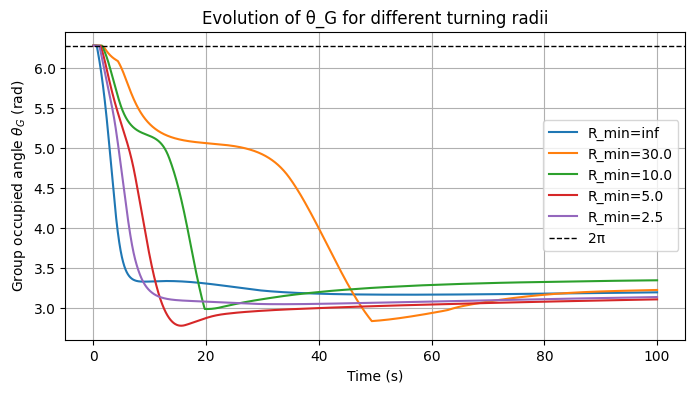

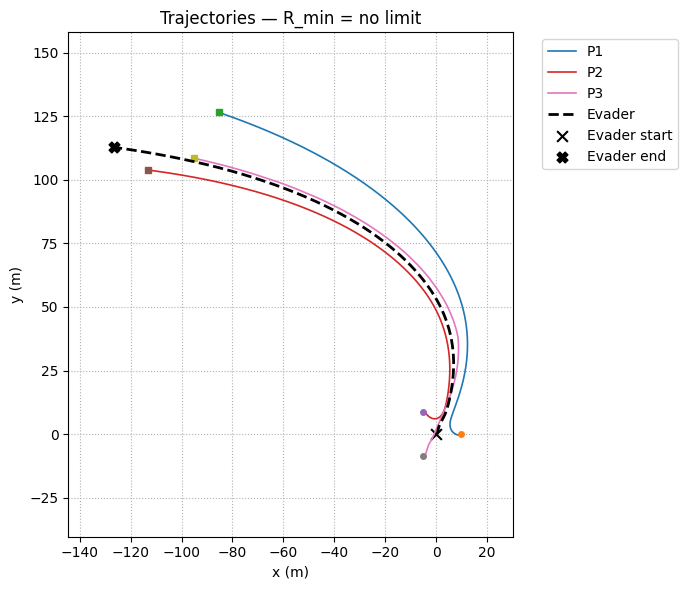

Saved: figures_turning_trajectories/trajectories_Rmin_inf.png


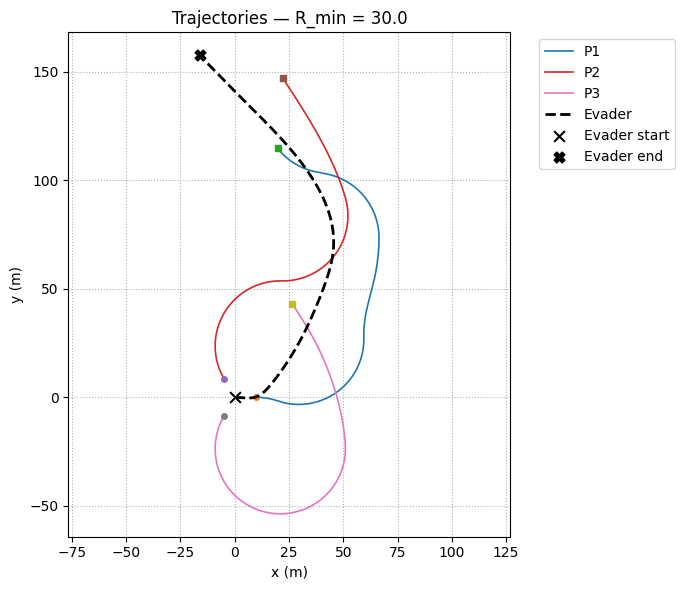

Saved: figures_turning_trajectories/trajectories_Rmin_30.0.png


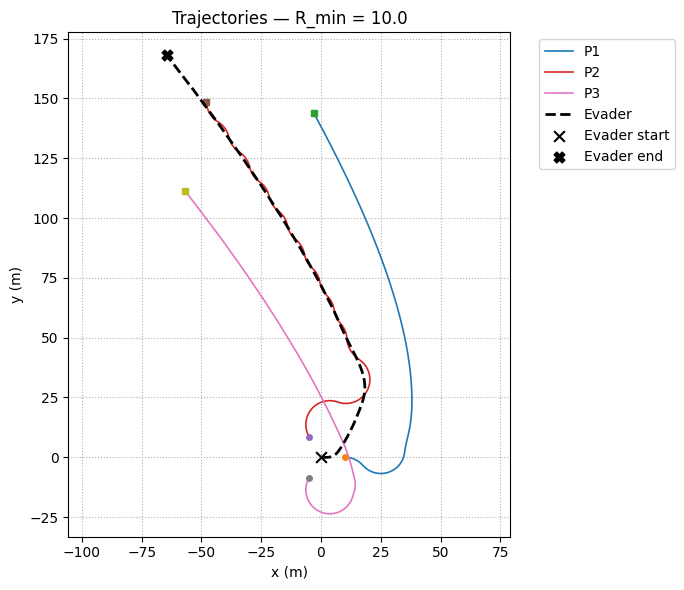

Saved: figures_turning_trajectories/trajectories_Rmin_10.0.png


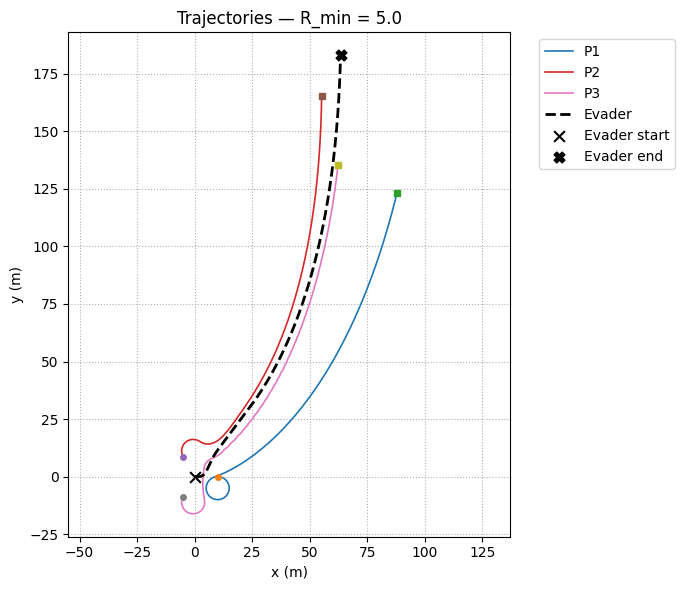

Saved: figures_turning_trajectories/trajectories_Rmin_5.0.png


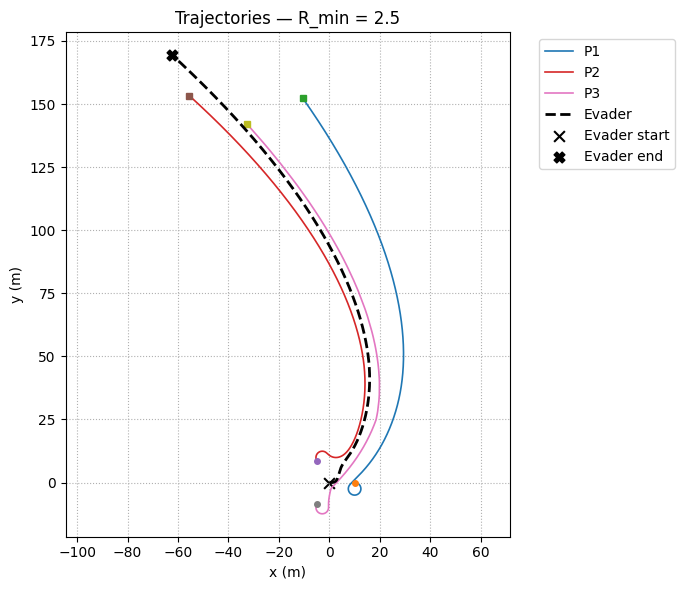

Saved: figures_turning_trajectories/trajectories_Rmin_2.5.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

R_vals = list(results.keys())
plt.figure(figsize=(8,4))
for R in R_vals:
    res = results[R]
    plt.plot(res['times'], res['thetaG'], label=f'R_min={R}')
plt.axhline(2*np.pi, color='k', linestyle='--', linewidth=1, label='2π')
plt.xlabel('Time (s)')
plt.ylabel(r'Group occupied angle $\theta_G$ (rad)')
plt.legend()
plt.title('Evolution of θ_G for different turning radii')
plt.grid(True)
plt.show()

out_dir = "figures_turning_trajectories"
os.makedirs(out_dir, exist_ok=True)

for R in R_vals:
    res = results[R]
    traj_p = np.array(res['traj_p'])   # (steps, N, 2)
    traj_e = np.array(res['traj_e'])   # (steps, 2)
    N = traj_p.shape[1]

    fig, ax = plt.subplots(figsize=(7,6))
    # plot pursuers
    for i in range(N):
        ax.plot(traj_p[:, i, 0], traj_p[:, i, 1], '-', lw=1.2, label=f'P{i+1}')
        ax.plot(traj_p[0, i, 0], traj_p[0, i, 1], 'o', markersize=4)   # start
        ax.plot(traj_p[-1, i, 0], traj_p[-1, i, 1], 's', markersize=4) # end
    # plot evader
    ax.plot(traj_e[:, 0], traj_e[:, 1], 'k--', lw=2, label='Evader')
    ax.scatter(traj_e[0, 0], traj_e[0, 1], marker='x', s=60, c='k', label='Evader start')
    ax.scatter(traj_e[-1, 0], traj_e[-1, 1], marker='X', s=60, c='k', label='Evader end')

    ax.set_title(f'Trajectories — R_min = {"no limit" if not np.isfinite(R) else R}')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.axis('equal')
    ax.grid(True, linestyle=':')
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

    plt.tight_layout()
    fname = f"trajectories_Rmin_{'inf' if not np.isfinite(R) else R}.png"
    fpath = os.path.join(out_dir, fname)
    fig.savefig(fpath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fpath}")


=== Running λ = 0.800 ===
R_min = inf, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
R_min = 30.0, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
R_min = 15.0, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
R_min = 10.0, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
R_min = 5.0, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
R_min = 2.5, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
  R_min = inf: ❌ Not encircled, final θ_G=2.70
  R_min = 30.0: ❌ Not encircled, final θ_G=3.68
  R_min = 15.0: ❌ Not encircled, final θ_G=2.71
  R_min = 10.0: ❌ Not encircled, final θ_G=2.68
  R_min = 5.0: ❌ Not encircled, final θ_G=2.53
  R_min = 2.5: ❌ Not encircled, final θ_G=2.62

=== Running λ = 0.850 ===
R_min = inf, Re_min = inf: Time limit reached (t = 40.00 s) — no capture or encirclement
R_min = 30.0, Re_min = inf: Time li

/tmp/ipykernel_16264/2142341129.py:98: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/prithish/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


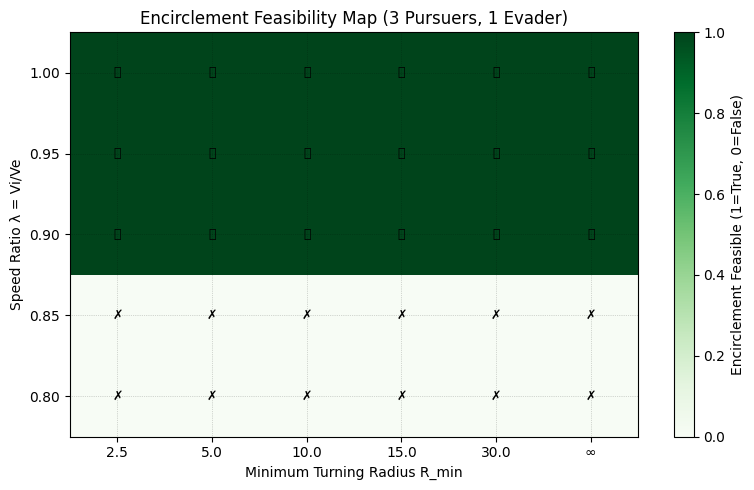

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------------------
# Sweep λ and R_min to test encirclement feasibility
# -------------------------------------------------------------
Ve = 2.0
dc = 1.0
r0 = 10.0
N = 3
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
pursuers0_base = np.stack([r0*np.cos(angles), r0*np.sin(angles)], axis=1)
evader0 = np.array([0.0, 0.0])

# λ values (speed ratios)
lambda_list = [0.8, 0.85, 0.9, 0.95, 1.0]

# Turning radii (maneuverability constraints)
R_list = [np.inf, 30.0, 15.0, 10.0, 5.0, 2.5]

# Simulation settings
dt = 0.01
max_t = 40.0

results_summary = []

for lam in lambda_list:
    Vi = lam * Ve
    cfg = {
        'case_name': f'lam{lam:.2f}',
        'Ve': Ve,
        'Vi': Vi,
        'lambda': lam,
        'pursuers0': pursuers0_base.copy(),
        'evader0': evader0.copy(),
        'dc': dc,
        'ke': 140.0
    }
    print(f"\n=== Running λ = {lam:.3f} ===")
    results = simulate_3pursuer_with_turning(cfg, R_list, dt=dt, max_t=max_t, verbose=False)

    for R in R_list:
        res = results[R]
        times = res['times']
        thetaG = np.array(res['thetaG'])
        encircled = np.any(thetaG >= 2*np.pi - 1e-3)  # <-- use encirclement condition
        t_final = times[-1] if len(times)>0 else np.nan
        final_theta = thetaG[-1] if len(thetaG)>0 else np.nan
        results_summary.append({
            'lambda': lam,
            'R_min': np.inf if not np.isfinite(R) else R,
            'encircled': encircled,
            't_final': t_final,
            'theta_final': final_theta
        })
        print(f"  R_min = {R}: {'⭕ Encircled' if encircled else '❌ Not encircled'}, final θ_G={final_theta:.2f}")

# -------------------------------------------------------------
# Summarize as a table
# -------------------------------------------------------------
df = pd.DataFrame(results_summary)
print("\n=== Summary ===")
print(df)

# -------------------------------------------------------------
# Plot encirclement feasibility map (robust version)
# -------------------------------------------------------------
# convert R_min=inf to placeholder for plotting
df_plot = df.copy()
df_plot['R_min_plot'] = df_plot['R_min'].replace(np.inf, 9999)

# pivot: λ vs R_min, 1 for encircled, 0 otherwise
pivot = df_plot.pivot_table(index='lambda', columns='R_min_plot',
                            values='encircled', aggfunc='max', fill_value=False)
Z = pivot.astype(int).values

plt.figure(figsize=(8,5))
im = plt.imshow(Z, cmap='Greens', origin='lower', aspect='auto')

# axis labels and ticks
plt.xticks(ticks=np.arange(len(pivot.columns)),
           labels=[r'∞' if x==9999 else str(x) for x in pivot.columns])
plt.yticks(ticks=np.arange(len(pivot.index)),
           labels=[f"{x:.2f}" for x in pivot.index])
plt.xlabel('Minimum Turning Radius R_min')
plt.ylabel('Speed Ratio λ = Vi/Ve')
plt.title('Encirclement Feasibility Map (3 Pursuers, 1 Evader)')
cbar = plt.colorbar(im, label='Encirclement Feasible (1=True, 0=False)')

# optional grid + text overlay
for i, lam in enumerate(pivot.index):
    for j, Rv in enumerate(pivot.columns):
        val = Z[i, j]
        plt.text(j, i, '⭕' if val else '✗', ha='center', va='center', color='black', fontsize=9)

plt.grid(which='both', color='k', linestyle=':', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()
